# Task 1: Problem & Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Spark Session

In [ ]:
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder \
    .appName("HIGGS_BigData_Project") \
    .getOrCreate()

2. Load Dataset

In [ ]:
df = spark.read.csv(
    "/content/drive/MyDrive/HIGGS.csv.gz",
    header=False,
    inferSchema=True
)

3. Rename Columns

In [ ]:
columns = [
"label","lepton_pt","lepton_eta","lepton_phi",
"missing_energy","missing_energy_phi",
"jet1_pt","jet1_eta","jet1_phi","jet1_btag",
"jet2_pt","jet2_eta","jet2_phi","jet2_btag",
"jet3_pt","jet3_eta","jet3_phi","jet3_btag",
"jet4_pt","jet4_eta","jet4_phi","jet4_btag",
"m_jj","m_jjj","m_lv","m_jlv",
"m_bb","m_wbb","m_wwbb"
]

df = df.toDF(*columns)

4. Dataset Inspection

In [ ]:
df.show(20)

+-----+------------------+--------------------+--------------------+------------------+--------------------+------------------+--------------------+--------------------+------------------+-------------------+-------------------+--------------------+------------------+------------------+--------------------+--------------------+-----------------+-------------------+--------------------+--------------------+-----------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+
|label|         lepton_pt|          lepton_eta|          lepton_phi|    missing_energy|  missing_energy_phi|           jet1_pt|            jet1_eta|            jet1_phi|         jet1_btag|            jet2_pt|           jet2_eta|            jet2_phi|         jet2_btag|           jet3_pt|            jet3_eta|            jet3_phi|        jet3_btag|            jet4_pt|            jet4_eta|            jet4_phi|        jet4_btag|           

In [ ]:
df.printSchema()

root
 |-- label: double (nullable = true)
 |-- lepton_pt: double (nullable = true)
 |-- lepton_eta: double (nullable = true)
 |-- lepton_phi: double (nullable = true)
 |-- missing_energy: double (nullable = true)
 |-- missing_energy_phi: double (nullable = true)
 |-- jet1_pt: double (nullable = true)
 |-- jet1_eta: double (nullable = true)
 |-- jet1_phi: double (nullable = true)
 |-- jet1_btag: double (nullable = true)
 |-- jet2_pt: double (nullable = true)
 |-- jet2_eta: double (nullable = true)
 |-- jet2_phi: double (nullable = true)
 |-- jet2_btag: double (nullable = true)
 |-- jet3_pt: double (nullable = true)
 |-- jet3_eta: double (nullable = true)
 |-- jet3_phi: double (nullable = true)
 |-- jet3_btag: double (nullable = true)
 |-- jet4_pt: double (nullable = true)
 |-- jet4_eta: double (nullable = true)
 |-- jet4_phi: double (nullable = true)
 |-- jet4_btag: double (nullable = true)
 |-- m_jj: double (nullable = true)
 |-- m_jjj: double (nullable = true)
 |-- m_lv: double (nulla

In [ ]:
print("Rows:", df.count())

Rows: 11000000


In [ ]:
print("Columns:", len(df.columns))

Columns: 29


5. File Size Verification

In [ ]:
import os

In [ ]:
size = os.path.getsize("/content/drive/MyDrive/HIGGS.csv.gz")

print("File Size (GB):", round(size/(1024**3),2))

File Size (GB): 2.62


6. Five V Evidence

In [ ]:
print("Partitions:", df.rdd.getNumPartitions())

Partitions: 1


# Task 2: Data Engineering

Missing Values

In [ ]:
from pyspark.sql.functions import col,isnan,when,count

In [ ]:
df.select([
count(
when(
col(c).isNull() | isnan(c),
c
)
).alias(c)
for c in df.columns
]).show()

+-----+---------+----------+----------+--------------+------------------+-------+--------+--------+---------+-------+--------+--------+---------+-------+--------+--------+---------+-------+--------+--------+---------+----+-----+----+-----+----+-----+------+
|label|lepton_pt|lepton_eta|lepton_phi|missing_energy|missing_energy_phi|jet1_pt|jet1_eta|jet1_phi|jet1_btag|jet2_pt|jet2_eta|jet2_phi|jet2_btag|jet3_pt|jet3_eta|jet3_phi|jet3_btag|jet4_pt|jet4_eta|jet4_phi|jet4_btag|m_jj|m_jjj|m_lv|m_jlv|m_bb|m_wbb|m_wwbb|
+-----+---------+----------+----------+--------------+------------------+-------+--------+--------+---------+-------+--------+--------+---------+-------+--------+--------+---------+-------+--------+--------+---------+----+-----+----+-----+----+-----+------+
|    0|        0|         0|         0|             0|                 0|      0|       0|       0|        0|      0|       0|       0|        0|      0|       0|       0|        0|      0|       0|       0|        0|   0|    

Duplicate Check

In [ ]:
total_rows = df.count()

unique_rows = df.dropDuplicates().count()

print("Duplicates:",
      total_rows - unique_rows)

Duplicates: 278698


In [ ]:
df = df.dropDuplicates()

print("Rows after removing duplicates:",
      df.count())

Rows after removing duplicates: 10721302


Class Distribution

In [ ]:
df.groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|  0.0|4892179|
|  1.0|5829123|
+-----+-------+



Repartition

In [ ]:
df = df.repartition(200)
print(df.rdd.getNumPartitions())

VectorAssembler

In [ ]:
from pyspark.ml.feature import VectorAssembler

In [ ]:
feature_cols = columns[1:]

assembler = VectorAssembler(
inputCols=feature_cols,
outputCol="features_raw"
)

StandardScaler

In [ ]:
from pyspark.ml.feature import StandardScaler

In [ ]:
scaler = StandardScaler(
inputCol="features_raw",
outputCol="features"
)

Pipeline

In [ ]:
from pyspark.ml import Pipeline

In [ ]:
pipeline = Pipeline(
stages=[
assembler,
scaler
]
)

In [ ]:
pipeline_model = pipeline.fit(df)

In [ ]:
processed_df = pipeline_model.transform(df)

In [ ]:
model_df = processed_df.sample(
    False,
    0.05,
    seed=42
)

Train Test Split

In [ ]:
train_df,test_df = model_df.randomSplit(
[0.8,0.2],
seed=42
)

# Task 3: ML Models

## Logistic Regression

In [ ]:
from pyspark.ml.classification import LogisticRegression

In [ ]:
lr = LogisticRegression(
labelCol="label",
featuresCol="features"
)

## Decision Tree

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(
labelCol="label",
featuresCol="features"
)

## Random Forest

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(
labelCol="label",
featuresCol="features"
)

## GBT

In [ ]:
from pyspark.ml.classification import GBTClassifier

In [ ]:
gbt = GBTClassifier(
    labelCol="label",
    featuresCol="features",
    maxBins=32,
    maxDepth=3,
    maxIter=5
)

## Param Grids

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder

In [ ]:
lr_grid = ParamGridBuilder() \
.addGrid(lr.regParam,[0.01]) \
.build()

In [ ]:
dt_grid = ParamGridBuilder() \
.addGrid(dt.maxDepth,[5]) \
.build()

In [ ]:
rf_grid = ParamGridBuilder() \
.addGrid(rf.numTrees,[20]) \
.build()

In [ ]:
gbt_grid = ParamGridBuilder() \
.addGrid(gbt.maxIter,[5,10]) \
.build()

## Evaluator

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [ ]:
evaluator = BinaryClassificationEvaluator(
labelCol="label"
)

## CrossValidator

In [ ]:
from pyspark.ml.tuning import CrossValidator

In [ ]:
cv_lr = CrossValidator(
estimator=lr,
estimatorParamMaps=lr_grid,
evaluator=evaluator,
numFolds=2
)

In [ ]:
cv_dt = CrossValidator(
    estimator=dt,
    estimatorParamMaps=dt_grid,
    evaluator=evaluator,
    numFolds=2,
    parallelism=4
)

In [ ]:
cv_rf = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_grid,
    evaluator=evaluator,
    numFolds=2,
    parallelism=4
)

In [ ]:
cv_gbt = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=gbt_grid,
    evaluator=evaluator,
    numFolds=2,
    parallelism=4
)

In [ ]:
train_df.cache()

train_df.count()

## Training Time

In [ ]:
import time

In [ ]:
start=time.time()

lr_model=cv_lr.fit(train_df)

end=time.time()

lr_time=round(end-start,2)

print(lr_time)

482.15282225608826


In [ ]:
start = time.time()

dt_model = cv_dt.fit(train_df)

end = time.time()

dt_time = round(end-start,2)

print("Decision Tree Training Time:", dt_time)

Decision Tree Training Time: 216.24


In [ ]:
start = time.time()

rf_model = cv_rf.fit(train_df)

end = time.time()

rf_time = round(end-start,2)

print("Random Forest Training Time:", rf_time)

Random Forest Training Time: 428.52


In [ ]:
start = time.time()

gbt_model = cv_gbt.fit(train_df)

end = time.time()

gbt_time = round(end-start,2)

print("GBT Training Time:", gbt_time)

GBT Training Time: 1998.09


# Task 4: Distributed Computing

Cache

In [ ]:
train_df.cache()

DataFrame[label: double, lepton_pt: double, lepton_eta: double, lepton_phi: double, missing_energy: double, missing_energy_phi: double, jet1_pt: double, jet1_eta: double, jet1_phi: double, jet1_btag: double, jet2_pt: double, jet2_eta: double, jet2_phi: double, jet2_btag: double, jet3_pt: double, jet3_eta: double, jet3_phi: double, jet3_btag: double, jet4_pt: double, jet4_eta: double, jet4_phi: double, jet4_btag: double, m_jj: double, m_jjj: double, m_lv: double, m_jlv: double, m_bb: double, m_wbb: double, m_wwbb: double, features_raw: vector, features: vector]

In [ ]:
train_df.count()

428745

Persist

In [ ]:
from pyspark import StorageLevel

In [ ]:
train_df.persist(
StorageLevel.MEMORY_AND_DISK
)

DataFrame[label: double, lepton_pt: double, lepton_eta: double, lepton_phi: double, missing_energy: double, missing_energy_phi: double, jet1_pt: double, jet1_eta: double, jet1_phi: double, jet1_btag: double, jet2_pt: double, jet2_eta: double, jet2_phi: double, jet2_btag: double, jet3_pt: double, jet3_eta: double, jet3_phi: double, jet3_btag: double, jet4_pt: double, jet4_eta: double, jet4_phi: double, jet4_btag: double, m_jj: double, m_jjj: double, m_lv: double, m_jlv: double, m_bb: double, m_wbb: double, m_wwbb: double, features_raw: vector, features: vector]

Resource Configuration

In [ ]:
for item in spark.sparkContext.getConf().getAll():
    print(item)

('spark.app.name', 'HIGGS_BigData_Project')
('spark.rdd.compress', 'True')
('spark.hadoop.fs.s3a.vectored.read.min.seek.size', '128K')
('spark.driver.host', '4d69e0c713d9')
('spark.executor.extraJavaOptions', '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-modules=jdk.incubator.vector --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --

Repartition Strategy

In [ ]:
train_df = train_df.repartition(200)

Spark UI

In [ ]:
print(
spark.sparkContext.uiWebUrl
)

http://4d69e0c713d9:4040


# Task 5: Evaluation & Stability

## Prediction

In [ ]:
eval_df = test_df.sample(
    False,
    0.1,
    seed=42
)

In [ ]:
lr_pred = lr_model.transform(eval_df)

In [ ]:
dt_pred = dt_model.transform(eval_df)

In [ ]:
rf_pred = rf_model.transform(eval_df)

In [ ]:
gbt_pred = gbt_model.transform(eval_df)

## Accuracy

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
acc_eval = MulticlassClassificationEvaluator(
labelCol="label",
predictionCol="prediction",
metricName="accuracy"
)

In [ ]:
lr_acc = acc_eval.evaluate(lr_pred)
dt_acc = acc_eval.evaluate(dt_pred)
rf_acc = acc_eval.evaluate(rf_pred)
gbt_acc = acc_eval.evaluate(gbt_pred)

In [ ]:
print("LR Accuracy:", lr_acc)

LR Accuracy: 0.6407731701747927


In [ ]:
print("DT Accuracy:", dt_acc)

DT Accuracy: 0.6671295498073132


In [ ]:
print("RF Accuracy:", rf_acc)

RF Accuracy: 0.6764586643802103


In [ ]:
print("GBT Accuracy:", gbt_acc)

GBT Accuracy: 0.7097303317380951


## Precision

In [ ]:
precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

In [ ]:
lr_precision = precision_eval.evaluate(lr_pred)
dt_precision = precision_eval.evaluate(dt_pred)
rf_precision = precision_eval.evaluate(rf_pred)
gbt_precision = precision_eval.evaluate(gbt_pred)

In [ ]:
print("LR Precision:", lr_precision)

LR Precision: 0.6412487807185193


In [ ]:
print("DT Precision:", dt_precision)

DT Precision: 0.6661062628496864


In [ ]:
print("RF Precision:", rf_precision)

RF Precision: 0.6760856070131274


In [ ]:
print("GBT Precision:", gbt_precision)

GBT Precision: 0.7091426213589087


## Recall

In [ ]:
recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

In [ ]:
lr_recall = recall_eval.evaluate(lr_pred)
dt_recall = recall_eval.evaluate(dt_pred)
rf_recall = recall_eval.evaluate(rf_pred)
gbt_recall = recall_eval.evaluate(gbt_pred)

In [ ]:
print("LR Recall:", lr_recall)

LR Recall: 0.6407731701747927


In [ ]:
print("DT Recall:", dt_recall)

DT Recall: 0.6671295498073133


In [ ]:
print("RF Recall:", rf_recall)

RF Recall: 0.6764586643802104


In [ ]:
print("GBT Recall:", gbt_recall)

GBT Recall: 0.7097303317380952


## F1 Score

In [ ]:
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

In [ ]:
lr_f1 = f1_eval.evaluate(lr_pred)
dt_f1 = f1_eval.evaluate(dt_pred)
rf_f1 = f1_eval.evaluate(rf_pred)
gbt_f1 = f1_eval.evaluate(gbt_pred)

In [ ]:
print("LR F1:", lr_f1)

LR F1: 0.6314325941740043


In [ ]:
print("DT F1:", dt_f1)

DT F1: 0.6662632887866798


In [ ]:
print("RF F1:", rf_f1)

RF F1: 0.6724061869340505


In [ ]:
print("GBT F1:", gbt_f1)

GBT F1: 0.7092794225086145


## AUC-ROC

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [ ]:
auc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [ ]:
lr_auc = auc_eval.evaluate(lr_pred)
dt_auc = auc_eval.evaluate(dt_pred)
rf_auc = auc_eval.evaluate(rf_pred)
gbt_auc = auc_eval.evaluate(gbt_pred)

In [ ]:
print("LR AUC:", lr_auc)

LR AUC: 0.6812340331598636


In [ ]:
print("DT AUC:", dt_auc)

DT AUC: 0.6622558198197906


In [ ]:
print("RF AUC:", rf_auc)

RF AUC: 0.7388902121832258


In [ ]:
print("GBT AUC:", gbt_auc)

GBT AUC: 0.7824438234131161


### Confusion Matrix - Logistic Regression

In [ ]:
print("LOGISTIC REGRESSION")

lr_pred.groupBy(
    "label",
    "prediction"
).count().show()

LOGISTIC REGRESSION
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0| 4588|
|  0.0|       1.0| 2649|
|  1.0|       0.0| 1315|
|  0.0|       0.0| 2345|
+-----+----------+-----+



### Confusion Matrix - Decision Tree

In [ ]:
print("DECISION TREE")

dt_pred.groupBy(
    "label",
    "prediction"
).count().show()

DECISION TREE
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0| 4157|
|  0.0|       1.0| 1920|
|  1.0|       0.0| 1746|
|  0.0|       0.0| 3074|
+-----+----------+-----+



### Confusion Matrix - Random Forest

In [ ]:
print("RANDOM FOREST")

rf_pred.groupBy(
    "label",
    "prediction"
).count().show()

RANDOM FOREST
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0| 4809|
|  0.0|       1.0| 2474|
|  1.0|       0.0| 1094|
|  0.0|       0.0| 2520|
+-----+----------+-----+



### Confusion Matrix - GBT

In [ ]:
print("GRADIENT BOOSTED TREES")

gbt_pred.groupBy(
    "label",
    "prediction"
).count().show()

GRADIENT BOOSTED TREES
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0| 4319|
|  0.0|       1.0| 1932|
|  1.0|       0.0| 1584|
|  0.0|       0.0| 3062|
+-----+----------+-----+



ROC + Precision-Recall Curve

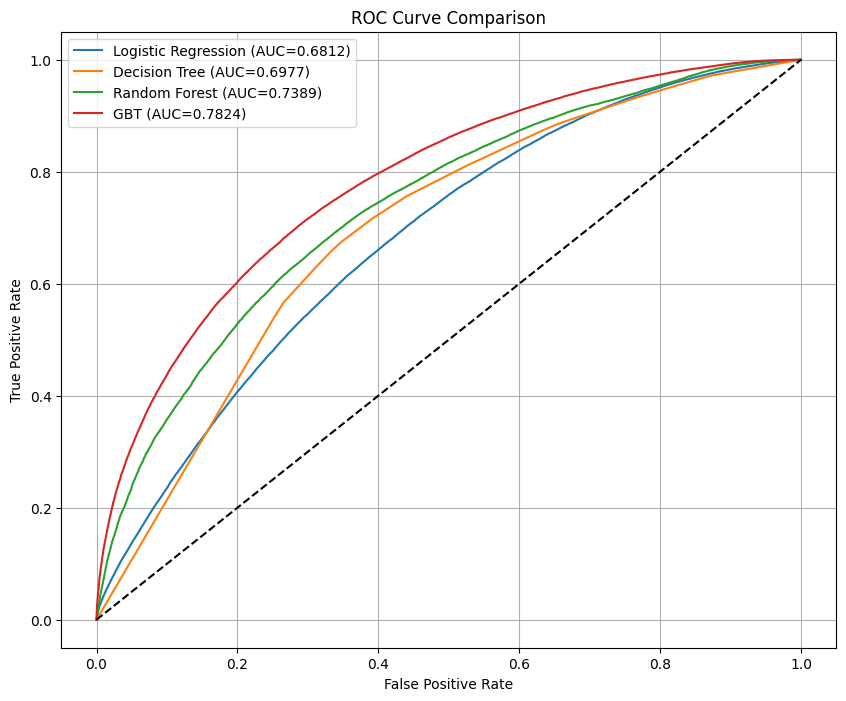

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Convert Spark predictions to Pandas

lr_pdf = lr_pred.select("label","probability").toPandas()
dt_pdf = dt_pred.select("label","probability").toPandas()
rf_pdf = rf_pred.select("label","probability").toPandas()
gbt_pdf = gbt_pred.select("label","probability").toPandas()

# Extract probability of positive class

lr_pdf["score"] = lr_pdf["probability"].apply(lambda x: float(x[1]))
dt_pdf["score"] = dt_pdf["probability"].apply(lambda x: float(x[1]))
rf_pdf["score"] = rf_pdf["probability"].apply(lambda x: float(x[1]))
gbt_pdf["score"] = gbt_pdf["probability"].apply(lambda x: float(x[1]))

# ROC CURVES

fpr_lr, tpr_lr, _ = roc_curve(
    lr_pdf["label"],
    lr_pdf["score"]
)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(
    dt_pdf["label"],
    dt_pdf["score"]
)
auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(
    rf_pdf["label"],
    rf_pdf["score"]
)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_gbt, tpr_gbt, _ = roc_curve(
    gbt_pdf["label"],
    gbt_pdf["score"]
)
auc_gbt = auc(fpr_gbt, tpr_gbt)

plt.figure(figsize=(10,8))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC={auc_lr:.4f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC={auc_dt:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={auc_rf:.4f})"
)

plt.plot(
    fpr_gbt,
    tpr_gbt,
    label=f"GBT (AUC={auc_gbt:.4f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

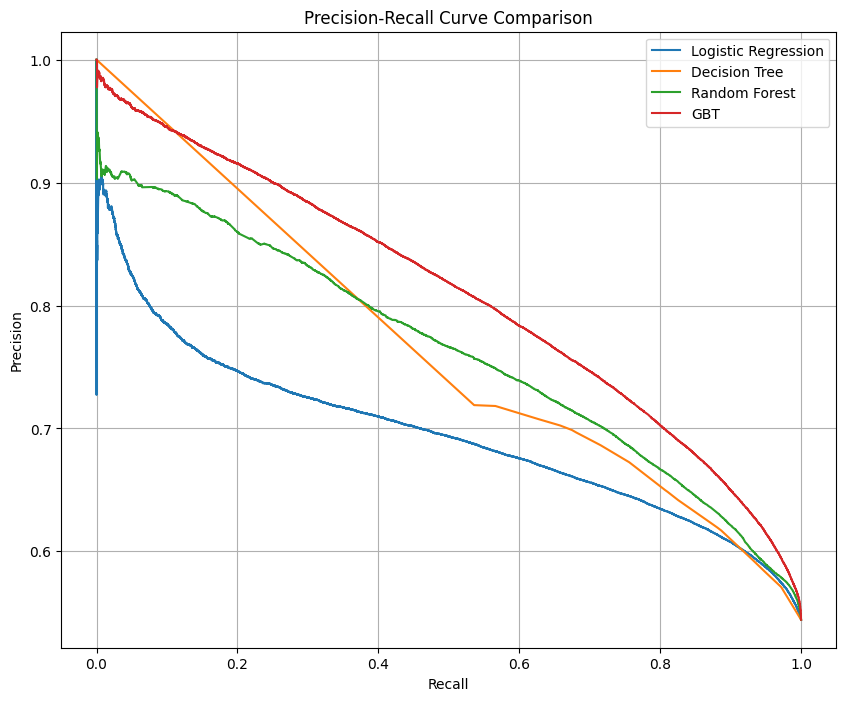

In [ ]:
# PRECISION-RECALL CURVES

precision_lr, recall_lr, _ = precision_recall_curve(
    lr_pdf["label"],
    lr_pdf["score"]
)

precision_dt, recall_dt, _ = precision_recall_curve(
    dt_pdf["label"],
    dt_pdf["score"]
)

precision_rf, recall_rf, _ = precision_recall_curve(
    rf_pdf["label"],
    rf_pdf["score"]
)

precision_gbt, recall_gbt, _ = precision_recall_curve(
    gbt_pdf["label"],
    gbt_pdf["score"]
)

plt.figure(figsize=(10,8))

plt.plot(
    recall_lr,
    precision_lr,
    label="Logistic Regression"
)

plt.plot(
    recall_dt,
    precision_dt,
    label="Decision Tree"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.plot(
    recall_gbt,
    precision_gbt,
    label="GBT"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

### Explainability

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
rf_best = rf_model.bestModel

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": list(rf_best.featureImportances)
})

importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
25,m_bb,0.392386
26,m_wbb,0.183778
27,m_wwbb,0.134385
22,m_jjj,0.083064
24,m_jlv,0.057338
5,jet1_pt,0.055947
3,missing_energy,0.038246
0,lepton_pt,0.019496
9,jet2_pt,0.012846
21,m_jj,0.010037


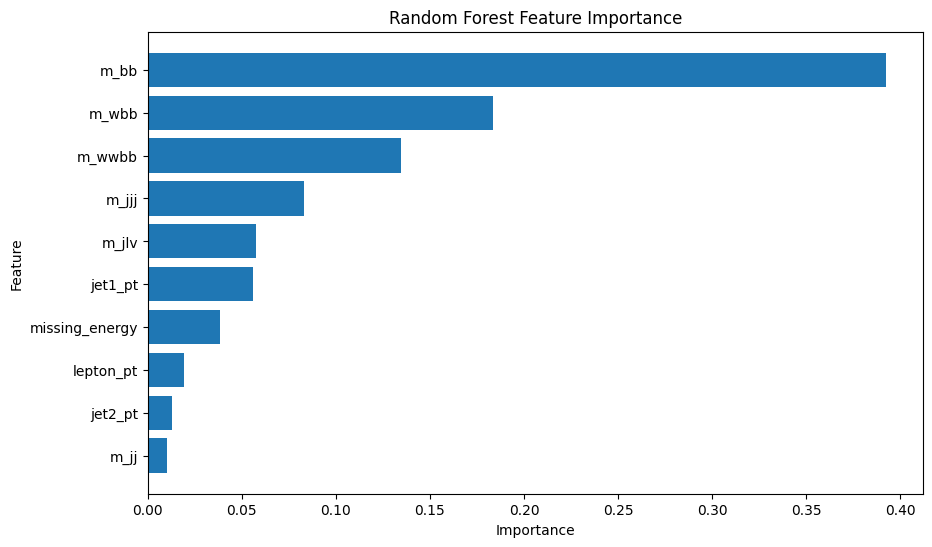

In [ ]:
top_features = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# Task 6: Tableau Export

In [ ]:
dashboard1 = pd.DataFrame({

    "Metric":[
        "Total Rows",
        "Total Columns",
        "Partitions",
        "Missing Values"
    ],

    "Value":[
        df.count(),
        len(df.columns),
        df.rdd.getNumPartitions(),
        0
    ]

})

dashboard1.to_csv(
    "dashboard1_data_quality.csv",
    index=False
)

In [ ]:
dashboard2 = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosted Trees"
    ],

    "Accuracy":[
        lr_acc,
        dt_acc,
        rf_acc,
        gbt_acc
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        rf_precision,
        gbt_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        rf_recall,
        gbt_recall
    ],

    "F1":[
        lr_f1,
        dt_f1,
        rf_f1,
        gbt_f1
    ],

    "AUC":[
        lr_auc,
        dt_auc,
        rf_auc,
        gbt_auc
    ]

})

dashboard2.to_csv(
    "dashboard2_model_performance.csv",
    index=False
)

In [ ]:
importance_df.to_csv(
    "dashboard3_business_insights.csv",
    index=False
)

In [ ]:
dashboard4 = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosted Trees"
    ],

    "Training_Time_Seconds":[
        lr_time,
        dt_time,
        rf_time,
        gbt_time
    ]

})

dashboard4.to_csv(
    "dashboard4_scalability.csv",
    index=False
)